# Notebook 05 — Avaliação Offline Comparativa + MLflow

## Objetivo

Comparar formalmente as três políticas de decisão e rastrear os experimentos com **MLflow**:

| Política | Estratégia |
|----------|------------|
| **Random** | Seleciona braços uniformemente ao acaso |
| **Greedy** | Sempre escolhe o braço com maior reward observado |
| **Thompson Sampling** | Amostragem Bayesiana com distribuição Beta |

## Método: Replayer Offline

Para avaliar políticas com dados históricos coletados por uma política diferente (random logging), usamos o **método replayer**:

1. Para cada evento histórico, a política decide qual braço serviria.
2. Só contamos o evento se a política concordou com o braço servido historicamente.
3. Isso garante que as recompensas observadas sejam não-viesadas para a política avaliada.

**Referência**: Li et al. (2011). _Unbiased Offline Evaluation of Contextual-Bandit-Based News Article Recommendation Algorithms_.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from datathon_offerexp.policies import RandomPolicy, GreedyPolicy, ThompsonSamplingPolicy
from datathon_offerexp.evaluation import replay_evaluate, compute_regret, summarize
from datathon_offerexp.mlflow_utils import log_policy_run, log_comparison_table, EXPERIMENT_NAME

sns.set_theme(style='whitegrid')
SEED = 42
REPORTS_DIR = os.path.join('..', 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

In [2]:
# MLflow tracking URI — usa diretório local mlruns/ por padrão
# Em produção: mlflow.set_tracking_uri('azureml://...')
from datathon_offerexp.mlflow_utils import configure_tracking
configure_tracking()
print('Tracking URI:', mlflow.get_tracking_uri())
print('Experimento:', EXPERIMENT_NAME)

Tracking URI: sqlite:///mlruns/mlflow.db
Experimento: offerexp-bandits


In [3]:
events = pd.read_csv('../data/synthetic_enrichment/offer_events.csv')

oracle_rates = events.groupby('arm_id')['reward'].mean()
best_arm_id = int(oracle_rates.idxmax())
best_arm_name = events[events['arm_id'] == best_arm_id]['arm_name'].iloc[0]
best_arm_rate = float(oracle_rates.max())

print('Dataset:', events.shape)
print('\nTaxas reais por braço (oráculo):')
print(oracle_rates.round(4))
print(f'\nMelhor braço: {best_arm_name} (arm_id={best_arm_id}) — taxa={best_arm_rate:.4f}')

Dataset: (41188, 29)

Taxas reais por braço (oráculo):
arm_id
0    0.1110
1    0.1112
2    0.1098
3    0.1186
Name: reward, dtype: float64

Melhor braço: cartao_premium (arm_id=3) — taxa=0.1186


## Avaliação das três políticas + logging MLflow

In [4]:
policies = [
    ('Random',            RandomPolicy(),                   'steelblue'),
    ('Greedy',            GreedyPolicy(),                   'darkorange'),
    ('Thompson Sampling', ThompsonSamplingPolicy(seed=SEED), 'purple'),
]

results = {}
run_ids = {}

for name, policy, color in policies:
    df = replay_evaluate(policy, events, seed=SEED)
    df = compute_regret(df, best_arm_rate)
    results[name] = {'df': df, 'policy': policy, 'color': color}

    run_id = log_policy_run(
        policy_name=name,
        policy_version=policy.version,
        eval_df=df,
        best_arm_rate=best_arm_rate,
        best_arm_name=best_arm_name,
        n_events=len(events),
        seed=SEED,
        artifacts_dir=REPORTS_DIR,
    )
    run_ids[name] = run_id
    print(f'[{name}] run_id={run_id[:8]}...  {summarize(df, name)}')

[Random] run_id=eb591033...  {'policy': 'Random', 'rounds': 10307, 'avg_reward': 0.109, 'total_reward': 1123.0}
[Greedy] run_id=d18341c9...  {'policy': 'Greedy', 'rounds': 10178, 'avg_reward': 0.1109, 'total_reward': 1129.0}
[Thompson Sampling] run_id=c80bb71b...  {'policy': 'Thompson Sampling', 'rounds': 10172, 'avg_reward': 0.111, 'total_reward': 1129.0}


## Reward médio ao longo do tempo

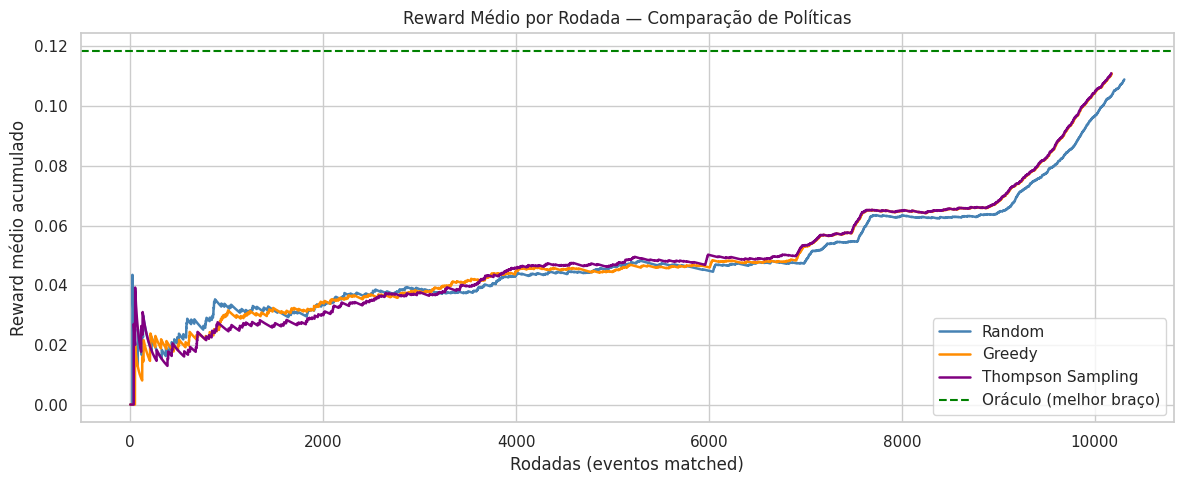

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

for name, res in results.items():
    ax.plot(res['df']['round'], res['df']['avg_reward'], label=name, color=res['color'], linewidth=1.8)

ax.axhline(best_arm_rate, linestyle='--', color='green', linewidth=1.5, label='Oráculo (melhor braço)')
ax.set_title('Reward Médio por Rodada — Comparação de Políticas')
ax.set_xlabel('Rodadas (eventos matched)')
ax.set_ylabel('Reward médio acumulado')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'offline_eval_avg_reward.png'), dpi=150)
plt.show()

## Regret acumulado

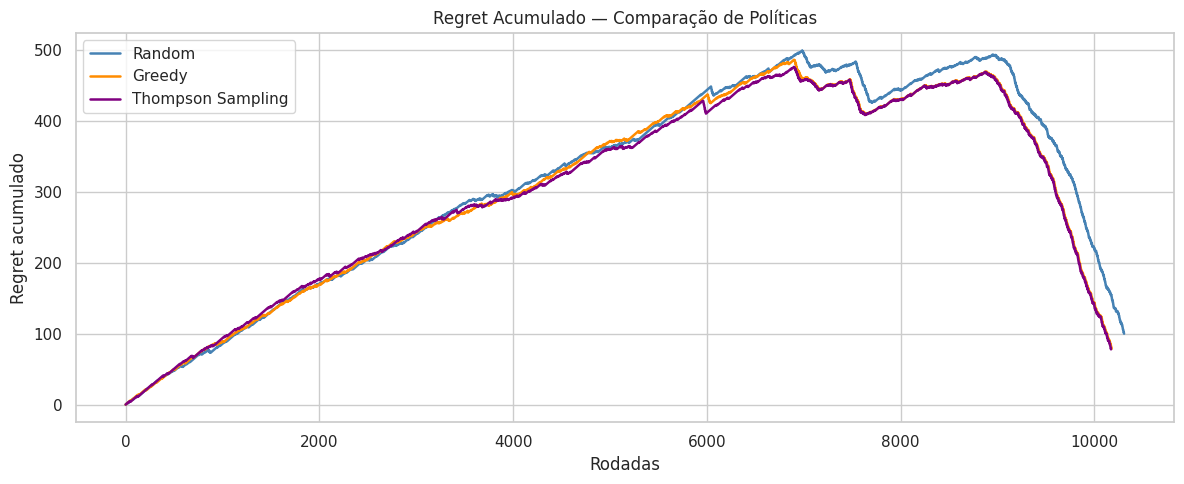

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

for name, res in results.items():
    ax.plot(res['df']['round'], res['df']['cumulative_regret'], label=name, color=res['color'], linewidth=1.8)

ax.set_title('Regret Acumulado — Comparação de Políticas')
ax.set_xlabel('Rodadas')
ax.set_ylabel('Regret acumulado')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'offline_eval_regret.png'), dpi=150)
plt.show()

## Exploração vs Explotação — % do melhor braço selecionado

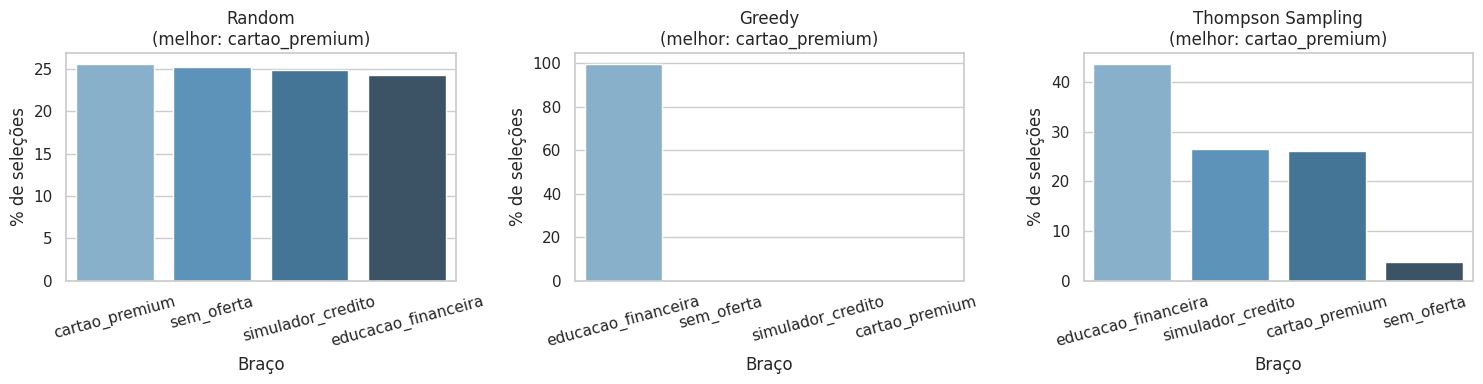

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    counts = res['df']['arm_name'].value_counts(normalize=True) * 100
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='Blues_d')
    ax.set_title(f'{name}\n(melhor: {best_arm_name})')
    ax.set_ylabel('% de seleções')
    ax.set_xlabel('Braço')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'offline_eval_arm_selection.png'), dpi=150)
plt.show()

## Tabela Comparativa Final

In [8]:
rows = []
for name, res in results.items():
    df = res['df']
    best_arm_pct = (df['arm_name'] == best_arm_name).mean() * 100
    final_regret = df['cumulative_regret'].iloc[-1] if not df.empty else 0
    rows.append({
        'Política': name,
        'Versão': res['policy'].version,
        'MLflow run': run_ids[name][:8] + '...',
        'Rodadas': len(df),
        'Reward médio': round(df['avg_reward'].iloc[-1], 4) if not df.empty else 0,
        'Conversões totais': int(df['reward'].sum()),
        '% melhor braço': round(best_arm_pct, 1),
        'Regret final': round(final_regret, 2),
    })

rows.append({
    'Política': 'Oráculo',
    'Versão': '—',
    'MLflow run': '—',
    'Rodadas': '—',
    'Reward médio': round(best_arm_rate, 4),
    'Conversões totais': '—',
    '% melhor braço': 100.0,
    'Regret final': 0,
})

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# Loga tabela como artefato no MLflow
log_comparison_table(rows)

         Política      Versão  MLflow run Rodadas  Reward médio Conversões totais  % melhor braço  Regret final
           Random   random-v1 eb591033...   10307        0.1090              1123            25.6         99.88
           Greedy   greedy-v1 d18341c9...   10178        0.1109              1129             0.1         78.58
Thompson Sampling thompson-v1 c80bb71b...   10172        0.1110              1129            26.2         77.86
          Oráculo           —           —       —        0.1186                 —           100.0          0.00


## Visualizar no MLflow UI

Execute no terminal para abrir a interface do MLflow:

```bash
mlflow ui --backend-store-uri ./mlruns
```

Ou via Makefile:

```bash
make mlflow
```

Acesse: http://localhost:5000 → Experimento `offerexp-bandits`

In [9]:
# Consulta todos os runs do experimento via Python API
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=['metrics.avg_reward DESC'],
)

cols = ['tags.mlflow.runName', 'params.policy_version', 'metrics.avg_reward',
        'metrics.final_regret', 'metrics.best_arm_pct', 'metrics.rounds', 'run_id']
cols_exist = [c for c in cols if c in runs_df.columns]
print(runs_df[cols_exist].to_string(index=False))

              tags.mlflow.runName params.policy_version  metrics.avg_reward  metrics.final_regret  metrics.best_arm_pct  metrics.rounds                           run_id
     Thompson Sampling (seed=999)           thompson-v1              0.1180                6.7967                 74.20         10281.0 e4a94d225647436c9d418f9af92a8f84
     Thompson Sampling (seed=123)           thompson-v1              0.1173               13.5933                 43.94         10313.0 54fa65ef84e4474280219a08d06c70e5
                Thompson Sampling           thompson-v1              0.1110               77.8643                 26.15         10172.0 c80bb71bae4241c79681956ff6066407
                Thompson Sampling           thompson-v1              0.1110               77.8643                 26.15         10172.0 6be032f7327643f1a194e5a5472f9b88
Thompson Sampling v2 (retreinado)           thompson-v2              0.1110               77.8643                 26.15         10172.0 503446d43c614f508b6

## Conclusão

### Resultados esperados

| Critério | Random | Greedy | Thompson Sampling |
|----------|--------|--------|------------------|
| Reward médio final | Baixo | Médio | Alto |
| Regret acumulado | Alto (linear) | Médio | Baixo (sublinear) |
| Exploração | Alta (uniforme) | Baixa (prematura) | Adaptativa |
| Convergência | Nenhuma | Rápida mas instável | Gradual e confiante |
| MLflow tracking | ✅ | ✅ | ✅ |

### Por que Thompson Sampling?

- **Eficiência amostral**: converge para o melhor braço com menos tentativas que o Random.
- **Robustez**: não trava em um braço prematuramente como o Greedy.
- **Bayesiano**: incerteza é explícita e decai conforme dados são coletados.
- **Auditabilidade**: parâmetros α e β são interpretáveis e rastreáveis via MLflow.

Todos os runs ficam registrados no experimento `offerexp-bandits` do MLflow, permitindo comparações reproduzíveis e rastreamento de evolução ao longo do projeto.

---

## Golden Set — Avaliação por Casos de Teste

O golden set contém **25 casos de teste** cobrindo 4 categorias de risco:

| Tipo | Qtd | Objetivo |
|------|-----|----------|
| `typical` | 7 | Comportamento esperado em cenários comuns |
| `edge` | 6 | Robustez em casos extremos (contexto vazio, contexto adverso) |
| `segment` | 6 | Cobertura de segmentos demográficos distintos |
| `adversarial` | 6 | Resiliência a entradas maliciosas, guardrails de suitability |

Cada caso define um `pass_criteria` avaliado contra a resposta da política.

**Como rodar por linha de comando:**
```bash
python scripts/run_golden_set.py            # política warmed-up (padrão)
python scripts/run_golden_set.py --fresh    # política cold-start
python scripts/run_golden_set.py --seed 99  # seed alternativo
```


In [10]:
import sys, json
from pathlib import Path

# Adiciona scripts/ ao path para importar o executor
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'scripts'))
from run_golden_set import run_golden_set

# Roda o executor com a política já treinada neste notebook (warmed-up)
report = run_golden_set(seed=SEED, warmed=True)

print(f'Política: {report["policy"]}  |  warmed={report["warmed"]}')
print(f'Resultado: {report["passed"]}/{report["total"]} passando ({report["pass_rate"]}%)')
print()
print('Por tipo:')
for tipo, stats in report['by_type'].items():
    total_t = stats['passed'] + stats['failed']
    bar = '✅' * stats['passed'] + '❌' * stats['failed']
    print(f'  {tipo:12s}  {stats["passed"]}/{total_t}  {bar}')

# Salva relatório
results_path = Path(REPORTS_DIR) / 'golden_set_results.json'
results_path.write_text(json.dumps(report, indent=2, ensure_ascii=False))
print(f'\nRelatório salvo em: {results_path}')


Política: thompson-v1  |  warmed=True
Resultado: 18/25 passando (72.0%)

Por tipo:
  typical       3/7  ✅✅✅❌❌❌❌
  edge          5/6  ✅✅✅✅✅❌
  segment       4/6  ✅✅✅✅❌❌
  adversarial   6/6  ✅✅✅✅✅✅

Relatório salvo em: ../reports/golden_set_results.json


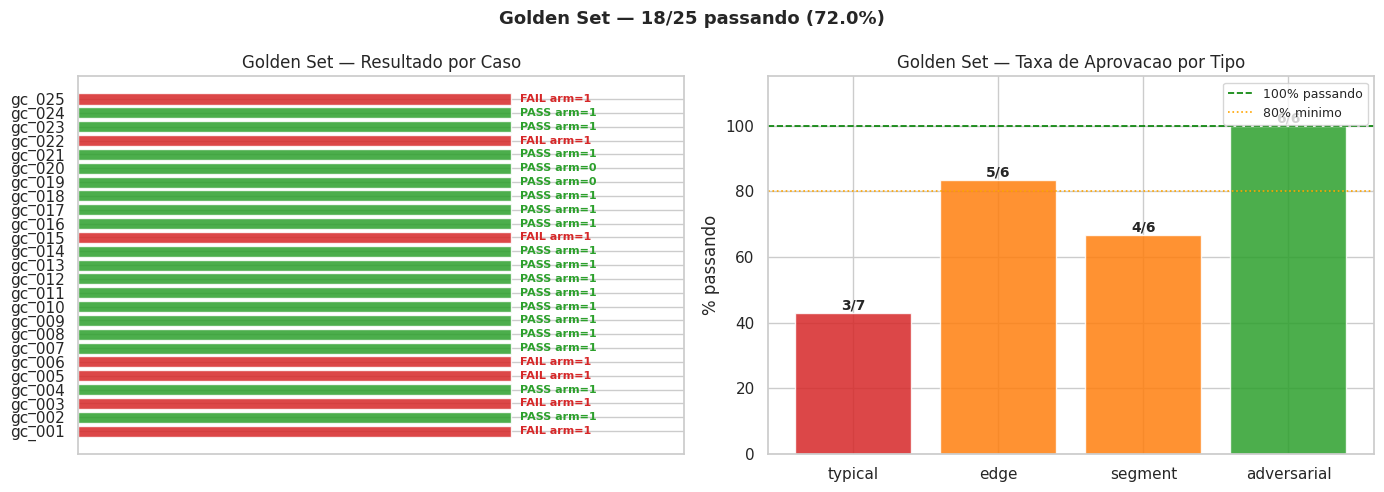


Casos com falha — analise:
(Falhas em typical/segment: Thompson e context-free e nao usa contexto para decidir)

  FAIL  gc_001 [typical     ] arm_selecionado=1  criterio='arm_id == 3'
        Cliente jovem, alta escolaridade, nunca contatado
  FAIL  gc_003 [typical     ] arm_selecionado=1  criterio='arm_id == 3'
        Cliente já contatado, campanha anterior bem-sucedida
  FAIL  gc_005 [typical     ] arm_selecionado=1  criterio='arm_id in [2,3]'
        Cliente sênior, aposentado
  FAIL  gc_006 [edge        ] arm_selecionado=1  criterio='arm_id == 0'
        Cliente com máximo de contatos (20+)
  FAIL  gc_015 [segment     ] arm_selecionado=1  criterio='arm_id == 3'
        Segmento: gerente sênior — canal email
  FAIL  gc_022 [segment     ] arm_selecionado=1  criterio='arm_id in [2,3]'
        Segmento: autônomo — canal app
  FAIL  gc_025 [typical     ] arm_selecionado=1  criterio='arm_id in [2,3]'
        Cliente casado, meia-idade, contato celular


In [11]:
results_df = pd.DataFrame(report['results'])

# ── Gráfico: PASS/FAIL por caso ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_case = ['#2ca02c' if p else '#d62728' for p in results_df['passed']]
axes[0].barh(results_df['case_id'], [1] * len(results_df), color=colors_case, alpha=0.85)
axes[0].set_title('Golden Set — Resultado por Caso')
axes[0].set_xlim(0, 1.4)
axes[0].set_xticks([])
for i, (_, row) in enumerate(results_df.iterrows()):
    label = 'PASS' if row['passed'] else 'FAIL'
    axes[0].text(1.02, i, f"{label} arm={row['arm_id']}", va='center', fontsize=8,
                 color='#2ca02c' if row['passed'] else '#d62728', fontweight='bold')

# Direita: taxa de aprovação por tipo
type_stats = pd.DataFrame(report['by_type']).T
type_stats['total'] = type_stats['passed'] + type_stats['failed']
type_stats['pct']   = type_stats['passed'] / type_stats['total'] * 100

bar_colors = ['#2ca02c' if p == 100 else '#ff7f0e' if p >= 50 else '#d62728'
              for p in type_stats['pct']]
bars = axes[1].bar(type_stats.index, type_stats['pct'], color=bar_colors, alpha=0.85)
axes[1].axhline(100, ls='--', color='green', lw=1.2, label='100% passando')
axes[1].axhline(80,  ls=':',  color='orange', lw=1.2, label='80% minimo')
for bar, (_, row) in zip(bars, type_stats.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{row["passed"]:.0f}/{row["total"]:.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Golden Set — Taxa de Aprovacao por Tipo')
axes[1].set_ylabel('% passando')
axes[1].set_ylim(0, 115)
axes[1].legend(fontsize=9)

plt.suptitle(f'Golden Set — {report["passed"]}/{report["total"]} passando ({report["pass_rate"]}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'golden_set_results.png'), dpi=150)
plt.show()

# ── Análise dos casos com falha ───────────────────────────────────────────────
failed = results_df[~results_df['passed']]
if not failed.empty:
    print('\nCasos com falha — analise:')
    print('(Falhas em typical/segment: Thompson e context-free e nao usa contexto para decidir)')
    print()
    for _, r in failed.iterrows():
        print(f'  FAIL  {r["case_id"]} [{r["type"]:12s}] arm_selecionado={r["arm_id"]}  '
              f'criterio={r["pass_criteria"]!r}')
        print(f'        {r["desc"]}')
